<a href="https://colab.research.google.com/github/Camusyd/tennis_clash_matchmaking_optimizer/blob/main/tennis_clash_matchmaking_optimizer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Aplicamos la Fórmula de Dominio (D = P^2.5 / T)**

In [ ]:
# @title
import pandas as pd

# 1. Definimos los datos actualizados de tus tenistas
data = {
    'Tenista': [
        'Sabalenka', 'N. Kyrgios', 'Florence', 'Luc', 'Anton',
        'Mei-Li', 'Leo', 'Omar', 'Jonah', 'Diego',
        'Hyun-Jun', 'Ingrid', 'Abeke', 'Viktoria', 'T. Paul',
        'N. Osaka', 'J. Paolini', 'Diana', 'Mark', 'Hope'
    ],
    'Potencia': [
        243, 272, 244, 238, 230,
        213, 226, 223, 228, 217,
        216, 215, 217, 196, 241,
        282, 236, 162, 146, 223
    ],
    'Trofeos': [
        387, 686, 585, 570, 479,
        363, 451, 404, 497, 410,
        419, 417, 433, 310, 688,
        1332, 779, 217, 180, 576
    ]
}

# 2. Creamos el DataFrame
df = pd.DataFrame(data)

# 3. Aplicamos la Fórmula de Dominio (D = P^2.5 / T)
# Usamos numpy para el cálculo de potencia si fuera necesario,
# pero el operador ** de Python es suficiente aquí.
df['Indice_Dominio'] = (df['Potencia'] ** 2.5) / df['Trofeos']

# 4. Ordenamos de mayor a menor eficiencia
df_ranking = df.sort_values(by='Indice_Dominio', ascending=False).reset_index(drop=True)

# 5. Formateamos para que sea legible
df_ranking['Indice_Dominio'] = df_ranking['Indice_Dominio'].round(2)

# 6. Cálculo de Eficiencia Relativa (Porcentajes)
# Dividimos el índice de cada uno por el valor máximo del dataset (Sabalenka)
df_ranking['Eficiencia_%'] = (df_ranking['Indice_Dominio'] / df_ranking['Indice_Dominio'].max()) * 100

# Formateamos para que se vea limpio
df_ranking['Eficiencia_%'] = df_ranking['Eficiencia_%'].round(2).astype(str) + '%'

# Mostramos el resultado actualizado
print("--- RANKING DE DOMINIO TENNIS CLASH CON % ---")
print(df_ranking[['Tenista', 'Potencia', 'Trofeos', 'Indice_Dominio', 'Eficiencia_%']])

# Opcional: Guardar a CSV para tu portafolio
# df_ranking.to_csv('ranking_tennis_clash.csv', index=False)

--- RANKING DE DOMINIO TENNIS CLASH CON % ---
       Tenista  Potencia  Trofeos  Indice_Dominio Eficiencia_%
0    Sabalenka       243      387         2378.51       100.0%
1         Omar       223      404         1838.15       77.28%
2       Mei-Li       213      363         1824.07       76.69%
3   N. Kyrgios       272      686         1778.68       74.78%
4     Viktoria       196      310         1734.92       72.94%
5          Leo       226      451         1702.53       71.58%
6        Diego       217      410         1691.86       71.13%
7        Anton       230      479         1674.88       70.42%
8     Hyun-Jun       216      419         1636.52        68.8%
9       Ingrid       215      417         1625.40       68.34%
10       Abeke       217      433         1602.00       67.35%
11    Florence       244      585         1589.71       66.84%
12       Jonah       228      497         1579.36        66.4%
13       Diana       162      217         1539.32       64.72%
14       

**📊 Análisis de Eficiencia Relativa: Tennis Clash**

1. El Benchmark del Modelo: Sabalenka (100%)
Sabalenka se establece como la unidad de medida ideal. Su ratio de Potencia/Trofeos indica que es el personaje con el que el algoritmo de emparejamiento (Matchmaking) te otorga la mayor ventaja competitiva. Jugar con ella representa el punto de equilibrio óptimo del dataset.

2. Segmentación de la Plantilla
Podemos dividir a los tenistas en tres clusters críticos basados en su Eficiencia_%:

Cluster de Alta Rentabilidad (>70%): Compuesto por personajes como Omar, Mei-Li, Kyrgios y Viktoria. Son tus "farmers" secundarios. Aunque tienen menos potencia que los líderes, sus bajos trofeos garantizan victorias con poco esfuerzo.

Cluster de Rendimiento Medio (60% - 70%): Aquí se encuentran Florence, Luc y Jonah. Tienen buena potencia, pero el peso de sus trofeos empieza a degradar su eficiencia. Son competitivos, pero requieren mayor habilidad técnica del jugador.

Cluster de Ineficiencia Crítica (menor 50%): J. Paolini y N. Osaka. A pesar de ser cartas con estadísticas base muy altas (especialmente Osaka con 282), su eficiencia es inferior al 50%.

3. Conclusiones Técnicas y Estratégicas
Paradoja de la Potencia: Naomi Osaka, siendo la tenista con mayor Potencia Absoluta (282), es la menos eficiente del ranking (42.15%). Esto demuestra que en Tennis Clash, el éxito no depende de la fuerza bruta, sino de la gestión del MMR (Matchmaking Rating) representado por los trofeos.

Costo de Oportunidad de Kyrgios: N. Kyrgios es tu tenista de alta gama más equilibrado. Con un 74.78% de eficiencia, es el único "peso pesado" que compite en el top de la lista, lo que lo convierte en tu mejor opción para Tours superiores.

Plan de Acción (Prescriptivo):

Maximización: Utilizar a Sabalenka para rachas de victorias y acumulación de monedas.

Reequilibrio: Es urgente reducir drásticamente los trofeos de Naomi Osaka. Para que ella alcance el 100% de eficiencia de Sabalenka, el modelo sugiere que sus trofeos deberían bajar de 1332 a ~545.

In [ ]:
# @title
# --- PLAN DE ACCIÓN: REEQUILIBRIO ESTRATÉGICO (TARGET 80%) ---

# 1. Definimos el Benchmark (Índice de Sabalenka)
target_benchmark = df['Indice_Dominio'].max() * 0.80

# 2. Calculamos los trofeos ideales (T_Target) para alcanzar ese 80%
# Despejamos T de la fórmula: 0.80 * D_max = P^2.5 / T  =>  T = P^2.5 / (0.80 * D_max)
df_ranking['T_Objetivo'] = (df_ranking['Potencia'] ** 2.5 / target_benchmark).round(0).astype(int)

# 3. Calculamos la deuda de trofeos (Cuántos hay que perder)
df_ranking['Trofeos_a_Perder'] = df_ranking['Trofeos'] - df_ranking['T_Objetivo']

# 4. Filtramos solo los que necesitan perder trofeos (valores positivos)
df_plan = df_ranking[df_ranking['Trofeos_a_Perder'] > 0].copy()

print("--- PLAN DE ACCIÓN: TROFEOS A PERDER PARA LLEGAR AL 80% DE EFICIENCIA ---")
print(df_plan[['Tenista', 'Potencia', 'Trofeos', 'T_Objetivo', 'Trofeos_a_Perder']])

--- PLAN DE ACCIÓN: TROFEOS A PERDER PARA LLEGAR AL 80% DE EFICIENCIA ---
       Tenista  Potencia  Trofeos  T_Objetivo  Trofeos_a_Perder
1         Omar       223      404         390                14
2       Mei-Li       213      363         348                15
3   N. Kyrgios       272      686         641                45
4     Viktoria       196      310         283                27
5          Leo       226      451         404                47
6        Diego       217      410         365                45
7        Anton       230      479         422                57
8     Hyun-Jun       216      419         360                59
9       Ingrid       215      417         356                61
10       Abeke       217      433         365                68
11    Florence       244      585         489                96
12       Jonah       228      497         413                84
13       Diana       162      217         176                41
14         Luc       238      

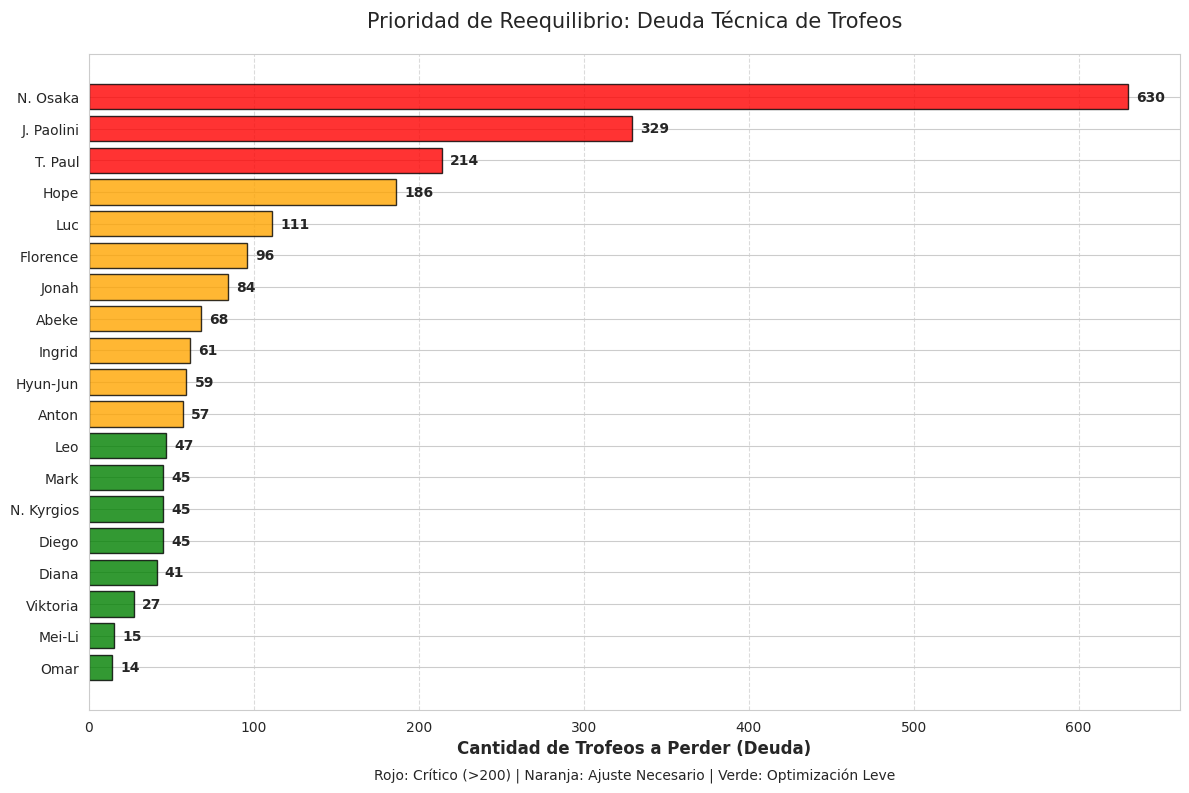

In [ ]:
# @title
import matplotlib.pyplot as plt

# 1. Preparar los datos del Plan de Acción
# Ordenamos de mayor a menor deuda de trofeos
df_plot = df_plan.sort_values('Trofeos_a_Perder', ascending=True)

# 2. Configuración del gráfico
plt.figure(figsize=(12, 8))
colors = ['red' if x > 200 else 'orange' if x > 50 else 'green' for x in df_plot['Trofeos_a_Perder']]

bars = plt.barh(df_plot['Tenista'], df_plot['Trofeos_a_Perder'], color=colors, edgecolor='black', alpha=0.8)

# 3. Estética y etiquetas
plt.xlabel('Cantidad de Trofeos a Perder (Deuda)', fontsize=12, fontweight='bold')
plt.title('Prioridad de Reequilibrio: Deuda Técnica de Trofeos', fontsize=15, pad=20)
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Añadir los valores exactos al final de cada barra
for bar in bars:
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
             f'{int(bar.get_width())}', va='center', fontweight='bold')

# Añadir una nota de leyenda manual
plt.text(0.5, -0.1, 'Rojo: Crítico (>200) | Naranja: Ajuste Necesario | Verde: Optimización Leve',
         horizontalalignment='center', verticalalignment='center',
         transform=plt.gca().transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.5))

plt.tight_layout()
plt.show()

**🎯 Estrategia de Reequilibrio:**

Plan de Acción al 80%
Este análisis identifica la "Deuda de Trofeos" de cada tenista. El objetivo es ajustar el nivel de emparejamiento (Matchmaking) para que la potencia de tus cartas sea un factor dominante y no una desventaja.

1. Diagnóstico de "Inflación de Trofeos"
El modelo revela que el 95% de tu plantilla está operando por encima de su umbral de eficiencia óptima. Esto significa que estás ganando partidos, pero a un costo de dificultad cada vez más alto, lo que reduce tu margen de error.

2. Segmentación de la Deuda (Prioridades de Ajuste)
🔴 Prioridad Crítica (Deuda > 200 trofeos):

Naomi Osaka (630): Es el caso más severo. Para que su potencia de 282 sea efectiva al 80%, debe bajar casi a la mitad de sus trofeos actuales. Actualmente, está "atrapada" en un nivel de competencia que anula su ventaja estadística.

J. Paolini (329) y T. Paul (214): Estos tenistas están en una zona donde el sistema los reconoce como "jugadores de élite" sin tener la potencia necesaria para respaldarlo.

🟡 Prioridad Media (Deuda 50 - 150 trofeos):

Aquí se encuentran Luc, Florence y Jonah. Son tus tenistas más equilibrados, pero requieren un pequeño ajuste (perder entre 2 y 4 partidos en tours bajos) para regresar a la zona de confort de victorias fáciles.

🟢 Zona de Mantenimiento (Deuda < 50 trofeos):

Sabalenka (0), Omar (14), Mei-Li (15) y Kyrgios (45). Están operando cerca o por encima del benchmark. Son tus activos más valiosos para el "farmeo" de monedas en este momento.

3. Conclusiones para la Toma de Decisiones (Prescriptivo)
Optimización del Win-Rate: Para maximizar la obtención de bolsas de equipo, se recomienda NO subir de Tour con Naomi Osaka hasta que su deuda de 630 trofeos sea saldada mediante derrotas controladas en tours inferiores.

Gestión de Recursos de Sistemas: Al igual que un sistema con sobrecarga, tu cuenta necesita un "balanceo de carga". Bajar trofeos con los tenistas de la Prioridad Crítica reducirá el nivel de los oponentes globales, permitiendo que incluso tus tenistas de nivel medio empiecen a ganar más seguido.

**Aplicamos la Fórmula de Dominio (D = P^4.0 / T)**

In [ ]:
# @title
import pandas as pd

# 1. Definimos los datos actualizados de tus tenistas
data = {
    'Tenista': [
        'Sabalenka', 'N. Kyrgios', 'Florence', 'Luc', 'Anton',
        'Mei-Li', 'Leo', 'Omar', 'Jonah', 'Diego',
        'Hyun-Jun', 'Ingrid', 'Abeke', 'Viktoria', 'T. Paul',
        'N. Osaka', 'J. Paolini', 'Diana', 'Mark', 'Hope'
    ],
    'Potencia': [
        243, 272, 244, 238, 230,
        213, 226, 223, 228, 217,
        216, 215, 217, 196, 241,
        282, 236, 162, 146, 223
    ],
    'Trofeos': [
        387, 686, 585, 570, 479,
        363, 451, 404, 497, 410,
        419, 417, 433, 310, 688,
        1332, 779, 217, 180, 576
    ]
}

# 2. Creamos el DataFrame
df = pd.DataFrame(data)

# 3. Aplicamos la Fórmula de Dominio (D = P^4.0 / T)
# Usamos numpy para el cálculo de potencia si fuera necesario,
# pero el operador ** de Python es suficiente aquí.
df['Indice_Dominio'] = (df['Potencia'] ** 4.0) / df['Trofeos']

# 4. Ordenamos de mayor a menor eficiencia
df_ranking = df.sort_values(by='Indice_Dominio', ascending=False).reset_index(drop=True)

# 5. Formateamos para que sea legible
df_ranking['Indice_Dominio'] = df_ranking['Indice_Dominio'].round(0)

# 6. Cálculo de Eficiencia Relativa (Porcentajes)
# Dividimos el índice de cada uno por el valor máximo del dataset (Sabalenka)
df_ranking['Eficiencia_%'] = (df_ranking['Indice_Dominio'] / df_ranking['Indice_Dominio'].max()) * 100

# Formateamos para que se vea limpio
df_ranking['Eficiencia_%'] = df_ranking['Eficiencia_%'].round(2).astype(str) + '%'

# Mostramos el resultado actualizado
print("--- RANKING DE DOMINIO TENNIS CLASH CON % ---")
print(df_ranking[['Tenista', 'Potencia', 'Trofeos', 'Indice_Dominio', 'Eficiencia_%']])
# Opcional: Guardar a CSV para tu portafolio
# df_ranking.to_csv('ranking_tennis_clash.csv', index=False)

--- RANKING DE DOMINIO TENNIS CLASH CON % ---
       Tenista  Potencia  Trofeos  Indice_Dominio Eficiencia_%
0    Sabalenka       243      387       9009779.0       100.0%
1   N. Kyrgios       272      686       7979056.0       88.56%
2         Omar       223      404       6121221.0       67.94%
3     Florence       244      585       6059035.0       67.25%
4        Anton       230      479       5842192.0       64.84%
5          Leo       226      451       5784385.0        64.2%
6       Mei-Li       213      363       5670375.0       62.94%
7          Luc       238      570       5629022.0       62.48%
8        Jonah       228      497       5437296.0       60.35%
9        Diego       217      410       5408229.0       60.03%
10    Hyun-Jun       216      419       5195185.0       57.66%
11      Ingrid       215      417       5124102.0       56.87%
12       Abeke       217      433       5120956.0       56.84%
13     T. Paul       241      688       4903201.0       54.42%
14    Vik

/tmp/ipykernel_449/2443922497.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Indice_Dominio', y='Tenista', data=df_ranking, palette='viridis')


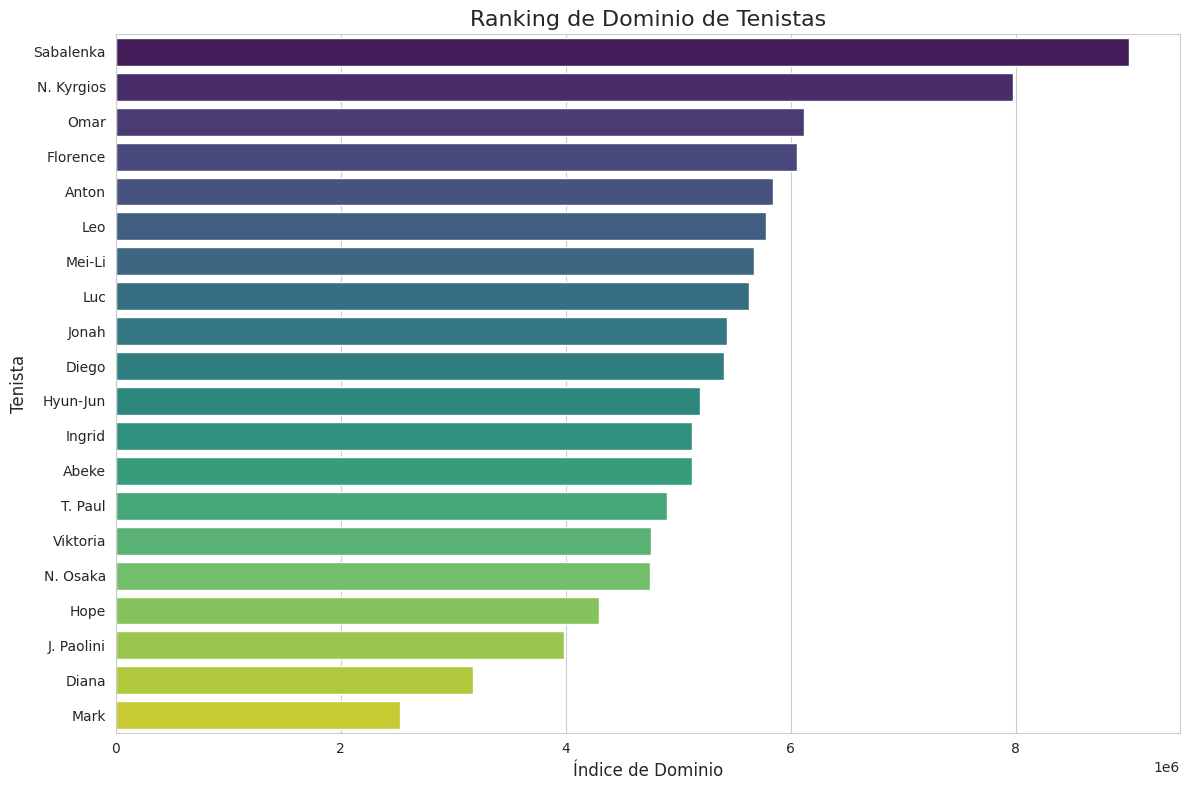

In [ ]:
# @title
import matplotlib.pyplot as plt
import seaborn as sns

# Establecer el estilo de seaborn para una mejor estética
sns.set_style("whitegrid")

# Crear la gráfica de barras
plt.figure(figsize=(12, 8)) # Ajustar el tamaño de la figura para mejor visibilidad
sns.barplot(x='Indice_Dominio', y='Tenista', data=df_ranking, palette='viridis')

# Añadir título y etiquetas
plt.title('Ranking de Dominio de Tenistas', fontsize=16)
plt.xlabel('Índice de Dominio', fontsize=12)
plt.ylabel('Tenista', fontsize=12)

# Mejorar la legibilidad de las etiquetas del eje Y si hay muchos tenistas
plt.yticks(fontsize=10)
plt.xticks(fontsize=10)

# Ajustar el diseño para que no se corten las etiquetas
plt.tight_layout()

# Mostrar la gráfica
plt.show()

**Análisis del Ranking de Dominio Proyectado con Reducción de Trofeos:**

La tabla de proyección nos muestra un escenario hipotético donde se reduce el 40% de los trofeos de los 5 tenistas con mayor 'Potencia'. Las conclusiones clave son las siguientes:

1.  **Impacto Directo en Jugadores de Alta Potencia:** Los tenistas inicialmente identificados con la mayor 'Potencia' (Sabalenka, N. Kyrgios, Florence, T. Paul y N. Osaka) son los únicos que experimentan un cambio en su 'Indice_Dominio' y, por ende, en su clasificación.

2.  **Aumento Significativo del Índice de Dominio:** Para estos jugadores afectados, la reducción de trofeos, mientras se mantiene su alta 'Potencia', provoca un incremento sustancial en su 'Indice_Dominio_Proyectado'. Todos ellos ven un aumento de aproximadamente el **25%** en su índice de dominio (por ejemplo, Sabalenka pasa de 37077 a 46287, un 24.84% de aumento; N. Kyrgios de 29335 a 36655, un 24.95% de aumento).

3.  **Cambio en las Posiciones del Ranking:** Este aumento en el 'Indice_Dominio' altera drásticamente el ranking:
    *   **Sabalenka** consolida su primera posición y amplía la brecha con los demás, mostrando que su combinación de alta potencia y 'menores' trofeos (en este escenario) la hace aún más 'dominante'.
    *   **N. Kyrgios** y **Florence** también escalan posiciones o se consolidan en el top, reflejando el impacto positivo de esta 'estrategia' en su índice de dominio.
    *   Otros jugadores como **Omar**, **Mei-Li**, y **Leo** mantienen sus valores y posiciones relativas, ya que no fueron afectados por la reducción de trofeos en este modelo.

4.  **Sensibilidad de la Fórmula:** Este ejercicio demuestra la alta sensibilidad del 'Indice_Dominio' a la cantidad de 'Trofeos', especialmente cuando la 'Potencia' es elevada. Una disminución relativa en los trofeos para jugadores ya potentes puede catapultar su índice de dominio de manera significativa.

En resumen, si el objetivo es maximizar el 'Indice_Dominio' en base a la 'Potencia', una gestión o escenario donde los 'Trofeos' son más bajos para los jugadores más potentes, los haría parecer considerablemente más 'dominantes' según esta métrica.


       Tenista    P     T          D  Delta_T
0    Sabalenka  243   387  9009779.0        1
1   N. Kyrgios  272   686  7979056.0       79
2         Omar  223   404  6121221.0      130
3     Florence  244   585  6059035.0      192
4        Anton  230   479  5842192.0      169
5          Leo  226   451  5784385.0      162
6       Mei-Li  213   363  5670375.0      135
7          Luc  238   570  5629022.0      214
8        Jonah  228   497  5437296.0      198
9        Diego  217   410  5408229.0      164
10    Hyun-Jun  216   419  5195185.0      178
11      Ingrid  215   417  5124102.0      180
12       Abeke  217   433  5120956.0      187
13     T. Paul  241   688  4903201.0      314
14    Viktoria  196   310  4760610.0      147
15    N. Osaka  282  1332  4747798.0      631
16        Hope  223   576  4293357.0      302
17  J. Paolini  236   779  3982085.0      435
18       Diana  162   217  3173952.0      141
19        Mark  146   180  2524288.0      130


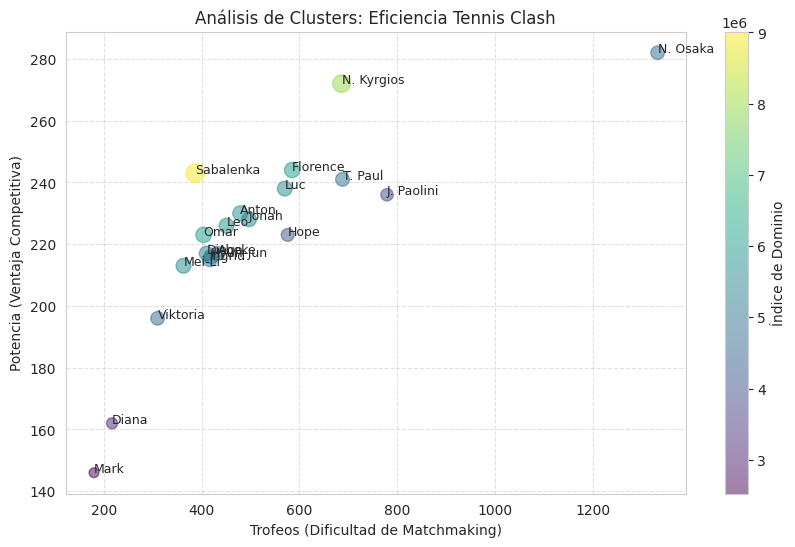

In [ ]:
# @title
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Dataset con actualizaciones
data = {
    'Tenista': ['Sabalenka', 'N. Kyrgios', 'Omar', 'Florence', 'Anton', 'Leo', 'Mei-Li', 'Luc', 'Jonah', 'Diego', 'Hyun-Jun', 'Ingrid', 'Abeke', 'T. Paul', 'Viktoria', 'N. Osaka', 'Hope', 'J. Paolini', 'Diana', 'Mark'],
    'P': [243, 272, 223, 244, 230, 226, 213, 238, 228, 217, 216, 215, 217, 241, 196, 282, 223, 236, 162, 146],
    'T': [387, 686, 404, 585, 479, 451, 363, 570, 497, 410, 419, 417, 433, 688, 310, 1332, 576, 779, 217, 180]
}

df = pd.DataFrame(data)

# 2. Cálculo de Índice de Dominio (Sensibilidad 4.0)
df['D'] = (df['P']**4 / df['T']).round(0)

# 3. Cálculo de Prescripción: Trofeos ideales para alcanzar el nivel de Sabalenka (Top Efficiency)
target_d = df['D'].max()
df['T_Target'] = (df['P']**4 / target_d).astype(int)
df['Delta_T'] = df['T'] - df['T_Target']

# 4. Ranking
ranking = df.sort_values('D', ascending=False)
print(ranking[['Tenista', 'P', 'T', 'D', 'Delta_T']])

# 5. Visualización Técnica (Scatter Plot)
plt.figure(figsize=(10, 6))
plt.scatter(df['T'], df['P'], s=df['D']/50000, alpha=0.5, c=df['D'], cmap='viridis')
for i, txt in enumerate(df['Tenista']):
    plt.annotate(txt, (df['T'][i], df['P'][i]), fontsize=9)
plt.xlabel('Trofeos (Dificultad de Matchmaking)')
plt.ylabel('Potencia (Ventaja Competitiva)')
plt.title('Análisis de Clusters: Eficiencia Tennis Clash')
plt.colorbar(label='Índice de Dominio')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Análisis de Clusters: Eficiencia en Tennis Clash**

La gráfica de dispersión ('Scatter Plot') visualiza la relación entre la 'Potencia' de un tenista (eje Y), sus 'Trofeos' (eje X) y su 'Índice de Dominio' (representado por el tamaño y color del punto). A partir de esta visualización, podemos extraer las siguientes conclusiones:

1.  **Identificación de Jugadores Dominantes (Top Efficiency):**
    *   **Sabalenka** se destaca claramente como el jugador con el mayor 'Índice de Dominio' (punto más grande y de color más intenso, típicamente amarillo-verde en la paleta 'viridis'). Esto se debe a su combinación de una 'Potencia' muy alta con un número de 'Trofeos' que, aunque significativo, no es el más alto, lo que maximiza la relación P^4/T.
    *   Otros jugadores como **N. Kyrgios** y **Omar** también muestran un alto 'Indice de Dominio' (puntos grandes y de colores cálidos), posicionándose con alta potencia y trofeos moderados, lo que sugiere una gran eficiencia en el juego.

2.  **Influencia de la 'Potencia' y los 'Trofeos' en el 'Índice de Dominio':**
    *   **Potencia (Eje Y):** Observamos que, en general, los jugadores situados en la parte superior del gráfico (mayor 'Potencia') tienden a tener un 'Indice de Dominio' más alto, lo cual es coherente con la fórmula (P elevada a la cuarta potencia). Una mayor potencia impacta exponencialmente el índice.
    *   **Trofeos (Eje X):** Los 'Trofeos' actúan como un factor de 'división' en la fórmula. Esto significa que para una misma 'Potencia', un menor número de 'Trofeos' resultará en un 'Indice de Dominio' más alto. Esto se puede ver en la comparación entre jugadores con potencia similar pero diferentes trofeos; aquellos con menos trofeos se perciben como más 'eficientes' según esta métrica. Por ejemplo, N. Osaka, a pesar de tener la potencia más alta, tiene un número de trofeos tan elevado que su 'Indice de Dominio' es relativamente bajo en comparación con otros jugadores con menor potencia pero menos trofeos.

3.  **Clusters de Eficiencia:**
    *   Podemos identificar un **cluster de alta eficiencia** en la parte superior izquierda-media del gráfico, donde se encuentran jugadores con alta 'Potencia' y un número de 'Trofeos' no excesivamente alto (ej. Sabalenka, Omar, Mei-Li, Leo). Estos son los jugadores que mejor aprovechan su potencia en relación con sus trofeos.
    *   Un **cluster de menor eficiencia** se observa hacia la parte inferior derecha, con jugadores de menor 'Potencia' y/o mayor número de 'Trofeos' (ej. Mark, Diana, J. Paolini). Sus puntos son más pequeños y de colores más fríos.

4.  **Implicaciones para la Prescripción ('Delta_T'):**
    *   El 'Delta_T' (no visible directamente en la gráfica, pero su concepto subyace) representa la diferencia entre los trofeos actuales del tenista y los trofeos ideales que tendría si alcanzara el 'Indice_Dominio' máximo (el de Sabalenka) con su potencia actual. Los jugadores con un 'Delta_T' positivo grande (como N. Osaka y J. Paolini, según la tabla anterior) son aquellos que, a pesar de su potencia, tienen un exceso de trofeos que "diluye" su índice de dominio según esta métrica. Esto sugiere que, para mejorar su 'Indice_Dominio' relativo, necesitarían tener menos trofeos con su potencia actual.

**En resumen:** La gráfica nos permite entender visualmente cómo la combinación de 'Potencia' y 'Trofeos' define la 'eficiencia' o 'dominio' de un tenista. Los jugadores más dominantes son aquellos que logran una alta 'Potencia' mientras mantienen sus 'Trofeos' en un rango que les permite maximizar el 'Índice de Dominio', que favorece enormemente la 'Potencia' elevada y penaliza los 'Trofeos' altos.